# CMT Convexity Correction Validation — Pucci (2014)

**Reference:** M. Pucci, *Constant Maturity Treasury Convexity Correction*, IJTAF 17(8), 2014. SSRN 3387961.

Visual validation of the credit-aware CMT convexity correction with three payoff variants (A, B, C).

## Contents
1. CC vs volatility — all three variants
2. CC vs hazard rate — credit dimension
3. No-default limit — collapse to Pelsser/Hagan CMS formula
4. Vega sign verification

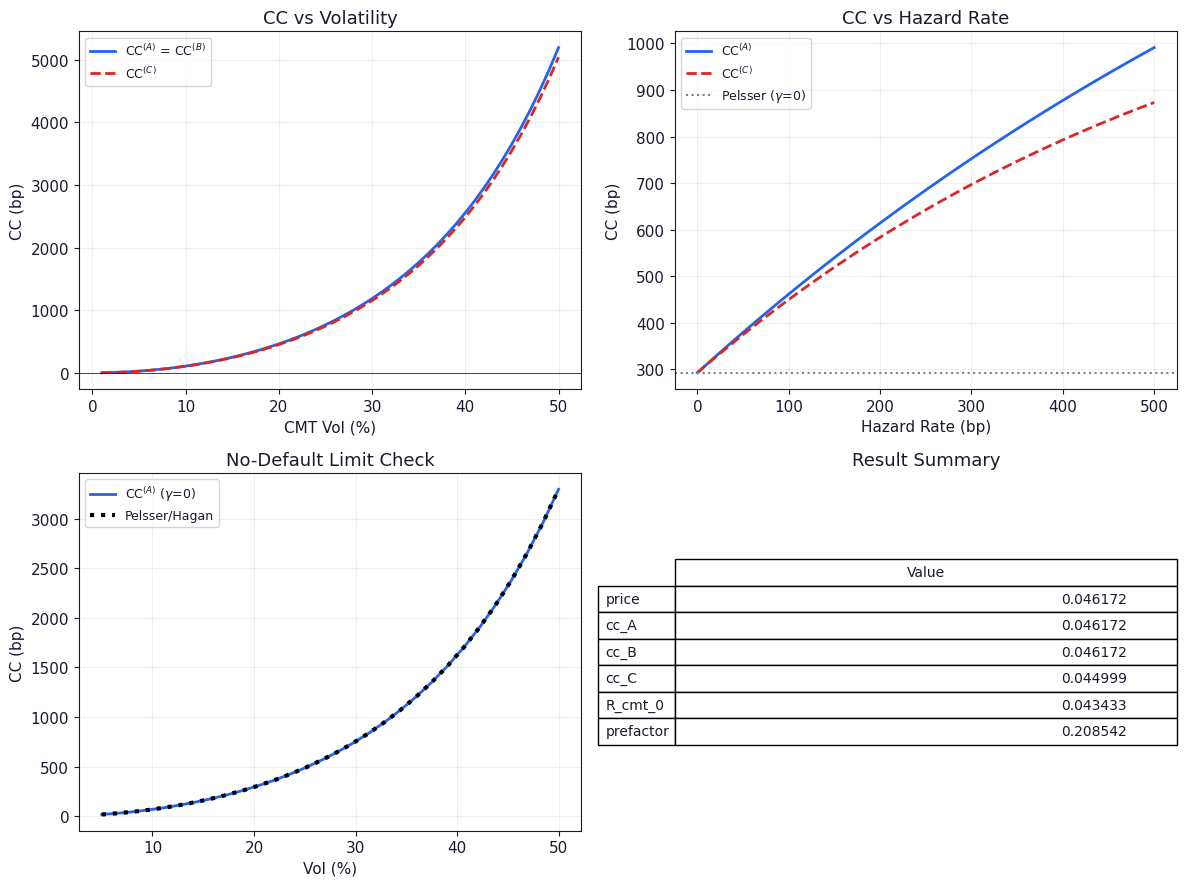

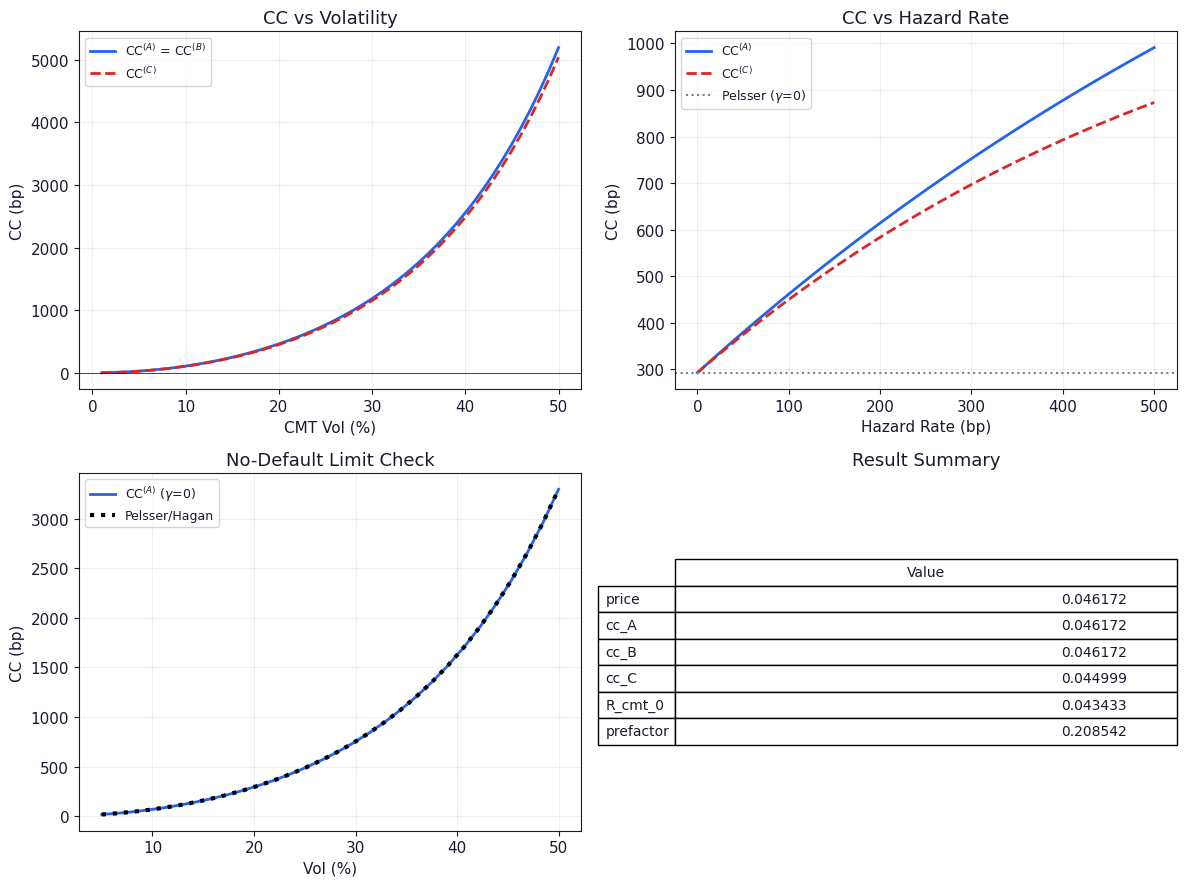

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "python"))

from datetime import date, timedelta
from pricebook.bootstrap import bootstrap
from pricebook.cmt import CMTInstrument
from pricebook.viz import plot, PlotBuilder

REF = date(2026, 4, 26)
deposits = [(REF + timedelta(days=91), 0.04), (REF + timedelta(days=182), 0.039)]
swaps = [(REF + timedelta(days=365), 0.038), (REF + timedelta(days=1825), 0.035),
         (REF + timedelta(days=3650), 0.034)]
curve = bootstrap(REF, deposits, swaps)

cmt = CMTInstrument(
    REF + timedelta(days=1825), REF + timedelta(days=2190),
    bond_tenor=10, sigma=0.20, hazard_rate=0.01)

# Default dashboard
plot(cmt, curve)

## 1. CC vs Volatility — Three Variants

$\text{CC}^{(A)} = \text{CC}^{(B)}$ (Eq 34), while $\text{CC}^{(C)}$ includes the fix-or-pre-default term (Eq 35).

At $\sigma = 0$, all three vanish. Positive vega for typical payment conventions.

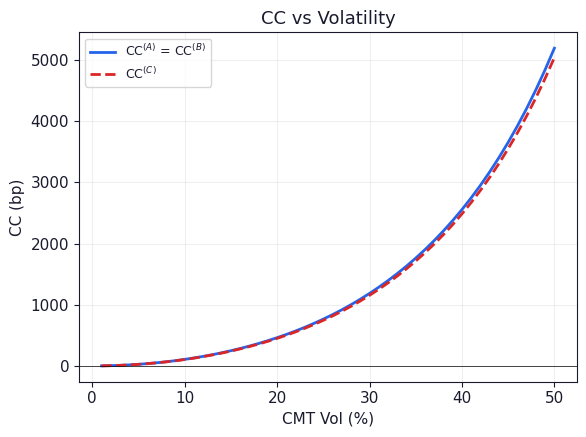

In [2]:
# CC vs volatility (3 variants)
PlotBuilder(cmt, curve).payoff().figure()

## 2. CC vs Hazard Rate — Credit Dimension

Higher hazard $\gamma$ increases the gap between CC$^{(C)}$ and CC$^{(A/B)}$.

At $\gamma = 0$, all three collapse to the Pelsser/Hagan CMS formula (Eq 37).

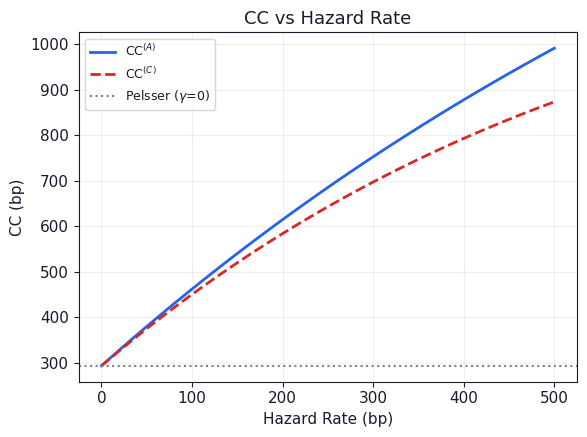

In [3]:
# CC vs hazard rate
PlotBuilder(cmt, curve).heatmap().figure()

## 3. No-Default Limit — Pelsser/Hagan Regression

At $\gamma = 0$: $\hat{D} = D$, $\hat{A} = A$, $\chi_0 = 1$, and all three CCs collapse to Eq (37):

$\text{CC} = (e^{\sigma^2 T_s} - 1)\left(1 - \alpha \frac{A_0}{D_{0,T_p}}\right)$

This is the cleanest regression test against any classical CMS pricer.

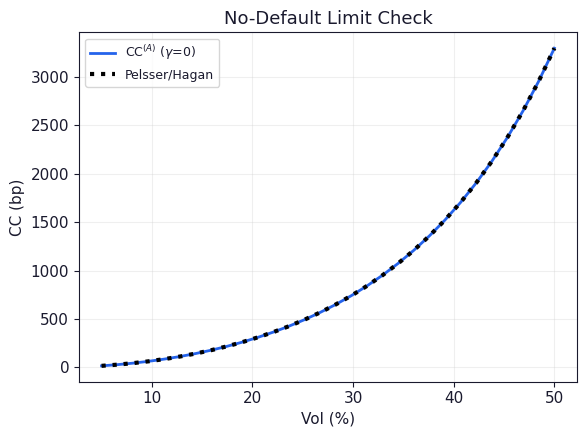

In [4]:
# No-default limit (Pelsser/Hagan)
PlotBuilder(cmt, curve).comparison().figure()